In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import re, math, textwrap
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
import seaborn as sns
import re
import warnings
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
warnings.filterwarnings("ignore")

# Optional: nice dataframe display in notebooks (falls back to print)
try:
    from IPython.display import display  # type: ignore
    def display_df(title, x):
        print(title)
        display(x)
except Exception:
    def display_df(title, x):
        print(title)
        print(x)


# Set the input path ONCE (edit this one line only)
CSV_PATH = Path('/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/csv_files/concatenated_phase_precession.csv')
phase_precession_DIR = CSV_PATH.parent
phase_precession_OUTDIR = CSV_PATH.parent.parent / "Analysis" / "Phase_Precession_analysis"

phase_precession_OUTDIR.mkdir(parents=True, exist_ok=True)
print("Saving outputs to:", phase_precession_OUTDIR)\

df_phase_precession = pd.read_csv(CSV_PATH) #select all cells in all trials


# check if parket file exists and is up to date, otherwise save to parquet for faster loading next time
PARQUET_PATH = os.path.join(phase_precession_OUTDIR, "phase_precession.parquet")
df_phase_precession.to_parquet(PARQUET_PATH, index=False)
df_phase_precession = pd.read_parquet(PARQUET_PATH)
print(df_phase_precession.head())

Saving outputs to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/Phase_Precession_analysis
                                            filename  channel  cluster  \
0  /home/robin/Documents/Science/SWC/jok_loukia_r...        5        2   
1  /home/robin/Documents/Science/SWC/jok_loukia_r...        4        3   
2  /home/robin/Documents/Science/SWC/jok_loukia_r...        1        4   
3  /home/robin/Documents/Science/SWC/jok_loukia_r...        5        4   
4  /home/robin/Documents/Science/SWC/jok_loukia_r...        1        7   

     Cell type Genotype         mouse_name run_direction  n_spikes     slope  \
0  Interneuron     NLGF  concatenated_data             e        70 -0.220723   
1  Interneuron     NLGF  concatenated_data             e       108  4.797076   
2  Interneuron     NLGF  concatenated_data             w         7 -2.195272   
3  Interneuron     NLGF  concatenated_data             e        40 -2.

In [18]:
df_negative_sig = df_phase_precession[
    (df_phase_precession["rho"] < 0) & (df_phase_precession["pval"] < 0.05) & (df_phase_precession["n_spikes"] > 5)
]

counts_by_genotype = (
    df_negative_sig.groupby(["Genotype", "Cell type"])
    .size()
    .unstack(fill_value=0)
)

print(f"Number of cells with rho < 0 and pval < 0.05: {len(df_negative_sig)}")
display_df("Counts of Pyramidal and Interneuron cells for each Genotype:", counts_by_genotype)

Number of cells with rho < 0 and pval < 0.05: 43
Counts of Pyramidal and Interneuron cells for each Genotype:


Cell type,Interneuron,Pyramidal
Genotype,,
NLGF,0,5
WT,4,34


### This cell analyses genotype differences in `rho` within `df_negative_sig` (cells with rho < 0 and pval < 0.05).

Specifically, it:
1) Tests normality of rho per genotype (Shapiro-Wilk).
2) Chooses the group comparison test:    - Tukey HSD if normality holds   - Pairwise Mann-Whitney U if normality is violated
3) Visualizes mean rho by genotype with:
   - barplot (mean ± CI/SEM-like error bars)
   - individual data points (stripplot)
 4) Annotates pairwise significance on the plot (U and p values).
 5) Saves the figure to `phase_precession_OUTDIR / "mean_rho_barplot.png"`.


In short: it tests and plots whether phase precession strength (rho) differs by genotype.

In [19]:
# Check normality per Genotype using Shapiro-Wilk test
from scipy.stats import shapiro, mannwhitneyu
from itertools import combinations

genotypes = df_negative_sig["Genotype"].unique()
normality_passed = True
for g in genotypes:
    stat, p = shapiro(df_negative_sig.loc[df_negative_sig["Genotype"] == g, "rho"])
    print(f"Shapiro-Wilk test for {g}: W={stat:.4f}, p={p:.4f}")
    if p < 0.05:
        normality_passed = False

# Collect pairwise results
genotype_order = ["WT"] + [g for g in sorted(genotypes) if g != "WT"]
pairwise_results = []
if normality_passed:
    print("\nNormality assumption holds — running Tukey's HSD test:")
    tukey = pairwise_tukeyhsd(endog=df_negative_sig["rho"], groups=df_negative_sig["Genotype"], alpha=0.05)
    print(tukey.summary())
else:
    print("\nNormality assumption violated — running pairwise Mann-Whitney U tests:")
    for g1, g2 in combinations(genotype_order, 2):
        x = df_negative_sig.loc[df_negative_sig["Genotype"] == g1, "rho"]
        y = df_negative_sig.loc[df_negative_sig["Genotype"] == g2, "rho"]
        stat, p = mannwhitneyu(x, y, alternative="two-sided")
        pairwise_results.append((g1, g2, stat, p))
        print(f"  {g1} vs {g2}: U={stat:.1f}, p={p:.4f}")

Shapiro-Wilk test for NLGF: W=0.9555, p=0.7761
Shapiro-Wilk test for WT: W=0.7298, p=0.0000

Normality assumption violated — running pairwise Mann-Whitney U tests:
  WT vs NLGF: U=57.0, p=0.1601


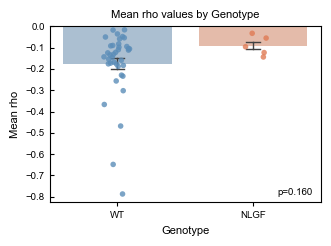

In [20]:
# Plotting the mean rho values for each Genotype with SEM and individual data points
import matplotlib as mpl

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.grid": False,
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "ytick.left": True,
    "ytick.direction": "in",
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})

GENO_ORDER  = ["WT", "NLGF"]                          # WT first
GENO_COLORS = {"NLGF": "#E07B54", "WT": "#5B8DB8"}   # orange / steel-blue

# Plotting the mean rho values for each Genotype with SEM and individual data points
fig, ax = plt.subplots(figsize=(3.35, 2.5))
sns.barplot(x="Genotype", y="rho", data=df_negative_sig, ci=68,
            estimator=np.mean, capsize=0.1, errwidth=1, order=GENO_ORDER, 
            palette=GENO_COLORS, ax=ax, alpha=0.55)
sns.stripplot(x="Genotype", y="rho", data=df_negative_sig, palette=GENO_COLORS,
              alpha=0.8, jitter=True, size=4, order=GENO_ORDER, ax=ax)

# Add significance brackets
# Add p-value annotation (bottom right)
if pairwise_results:
    for g1, g2, stat, pval in pairwise_results:
        if not normality_passed:
            label = "p<0.001" if pval < 0.001 else f"p={pval:.3f}"
        else:
            label = "p-adj<0.001" if pval < 0.001 else f"p-adj={pval:.3f}"
        ax.text(0.97, 0.03, label, transform=ax.transAxes,
                ha="right", va="bottom", fontsize=7)

ax.set_title("Mean rho values by Genotype")
ax.set_xlabel("Genotype")
ax.set_ylabel("Mean rho")
plt.tight_layout()
plt.savefig(phase_precession_OUTDIR / "mean_rho_barplot.png")
plt.show()

In [25]:
# Chi-square test: proportion of phase-precessing cells (rho<0 & pval<0.05) by Genotype
df_phase_precession["phase_precessing"] = (
    (df_phase_precession["rho"] < 0) & (df_phase_precession["pval"] < 0.05) & (df_phase_precession["n_spikes"] > 5)
)

contingency = pd.crosstab(df_phase_precession["Genotype"], df_phase_precession["phase_precessing"],
                           margins=False)
contingency.columns = ["Non-precessing", "Precessing"]
genotype_order = ["WT"] + [g for g in contingency.index if g != "WT"]
contingency = contingency.loc[genotype_order]
display_df("Contingency table:", contingency)
save_csv_path = phase_precession_OUTDIR / "phase_precession_contingency.csv"
contingency.to_csv(save_csv_path)
print(f"Contingency table saved to: {save_csv_path}")

from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square test: chi2={chi2:.4f}, p-value={p:.4f}, dof={dof}")
print(f"Expected counts:\n{pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(1)}")

# Show proportions
proportions = contingency.div(contingency.sum(axis=1), axis=0)
display_df("\nProportion of precessing cells per Genotype:", proportions)
save_csv_path = phase_precession_OUTDIR / "phase_precession_proportions.csv"
proportions.to_csv(save_csv_path)
print(f"Proportions saved to: {save_csv_path}")

Contingency table:


,Non-precessing,Precessing
Genotype,,
WT,185,38
NLGF,102,5


Contingency table saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/Phase_Precession_analysis/phase_precession_contingency.csv

Chi-square test: chi2=8.6984, p-value=0.0032, dof=1
Expected counts:
          Non-precessing  Precessing
Genotype                            
WT                 193.9        29.1
NLGF                93.1        13.9

Proportion of precessing cells per Genotype:


,Non-precessing,Precessing
Genotype,,
WT,0.829596,0.170404
NLGF,0.953271,0.046729


Proportions saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/Phase_Precession_analysis/phase_precession_proportions.csv


In [ ]:
# Check normality per Genotype using Shapiro-Wilk test (Pyramidal only)
from scipy.stats import shapiro, mannwhitneyu
from itertools import combinations

df_negative_sig_pyr = df_negative_sig[df_negative_sig["Cell type"] == "Pyramidal"]

genotypes = df_negative_sig_pyr["Genotype"].unique()
normality_passed = True
for g in genotypes:
    stat, p = shapiro(df_negative_sig_pyr.loc[df_negative_sig_pyr["Genotype"] == g, "rho"])
    print(f"Shapiro-Wilk test for {g}: W={stat:.4f}, p={p:.4f}")
    if p < 0.05:
        normality_passed = False

# Collect pairwise results
genotype_order = ["WT"] + [g for g in sorted(genotypes) if g != "WT"]
pairwise_results = []
if normality_passed:
    print("\nNormality assumption holds — running Tukey's HSD test:")
    tukey = pairwise_tukeyhsd(endog=df_negative_sig_pyr["rho"], groups=df_negative_sig_pyr["Genotype"], alpha=0.05)
    print(tukey.summary())
else:
    print("\nNormality assumption violated — running pairwise Mann-Whitney U tests:")
    for g1, g2 in combinations(genotype_order, 2):
        x = df_negative_sig_pyr.loc[df_negative_sig_pyr["Genotype"] == g1, "rho"]
        y = df_negative_sig_pyr.loc[df_negative_sig_pyr["Genotype"] == g2, "rho"]
        stat, p = mannwhitneyu(x, y, alternative="two-sided")
        pairwise_results.append((g1, g2, stat, p))
        print(f"  {g1} vs {g2}: U={stat:.1f}, p={p:.4f}")

# Plotting the mean rho values for each Genotype with SEM and individual data points (Pyramidal only)
fig, ax = plt.subplots(figsize=(8, 6))
palette = {g: "orange" if g == "NLGF" else "skyblue" for g in genotype_order}
sns.barplot(x="Genotype", y="rho", data=df_negative_sig_pyr, ci=68,
            estimator=np.mean, capsize=0.1, errwidth=1.5, order=genotype_order, 
            palette=palette, ax=ax)
sns.stripplot(x="Genotype", y="rho", data=df_negative_sig_pyr, color="black", alpha=0.4, 
              jitter=True, size=4, order=genotype_order, ax=ax)

# Add significance brackets
if pairwise_results:
    y_max = df_negative_sig_pyr["rho"].max()
    y_range = df_negative_sig_pyr["rho"].max() - df_negative_sig_pyr["rho"].min()
    step = y_range * 0.08
    idx_map = {g: i for i, g in enumerate(genotype_order)}
    for k, (g1, g2, stat, pval) in enumerate(pairwise_results):
        x1, x2 = idx_map[g1], idx_map[g2]
        y = y_max + step * (k + 1)
        if pval < 0.001:
            label = f"U={stat:.0f}, p<0.001"
        else:
            label = f"U={stat:.0f}, p={pval:.3f}"
        ax.plot([x1, x1, x2, x2], [y - step * 0.2, y, y, y - step * 0.2], color="black", lw=1)
        ax.text((x1 + x2) / 2, y, label, ha="center", va="bottom", fontsize=8)

ax.set_title("Mean rho values by Genotype (Pyramidal only)")
ax.set_xlabel("Genotype")
ax.set_ylabel("Mean rho")
plt.tight_layout()
plt.savefig(phase_precession_OUTDIR / "mean_rho_barplot_pyramidal.png")
plt.show()

In [ ]:
# Chi-square test: proportion of phase-precessing PYRAMIDAL cells by Genotype
df_pyramidal = df_phase_precession[df_phase_precession["Cell type"] == "Pyramidal"].copy()
df_pyramidal["phase_precessing"] = (
    (df_pyramidal["rho"] < 0) & (df_pyramidal["pval"] < 0.05)
)

contingency_pyr = pd.crosstab(df_pyramidal["Genotype"], df_pyramidal["phase_precessing"], margins=False)
contingency_pyr.columns = ["Non-precessing", "Precessing"]
genotype_order = ["WT"] + [g for g in contingency_pyr.index if g != "WT"]
contingency_pyr = contingency_pyr.loc[genotype_order]
display_df("Contingency table (Pyramidal only):", contingency_pyr)
save_csv_path = phase_precession_OUTDIR / "phase_precession_contingency_pyramidal.csv"
contingency_pyr.to_csv(save_csv_path)
print(f"Contingency table saved to: {save_csv_path}")

chi2, p, dof, expected = chi2_contingency(contingency_pyr)
print(f"\nChi-square test (Pyramidal only): chi2={chi2:.4f}, p-value={p:.4f}, dof={dof}")
print(f"Expected counts:\n{pd.DataFrame(expected, index=contingency_pyr.index, columns=contingency_pyr.columns).round(1)}")

proportions_pyr = contingency_pyr.div(contingency_pyr.sum(axis=1), axis=0)
display_df("\nProportion of precessing Pyramidal cells per Genotype:", proportions_pyr)
save_csv_path = phase_precession_OUTDIR / "phase_precession_proportions_pyramidal.csv"
proportions_pyr.to_csv(save_csv_path)
print(f"Proportions saved to: {save_csv_path}")

In [ ]:
# Chi-square test: proportion of phase-precessing PYRAMIDAL cells by Genotype
df_pyramidal = df_phase_precession[df_phase_precession["Cell type"] == "Pyramidal"].copy()
df_pyramidal["phase_precessing"] = (
    (df_pyramidal["rho"] < 0) & (df_pyramidal["pval"] < 0.05)
)

contingency_pyr = pd.crosstab(df_pyramidal["Genotype"], df_pyramidal["phase_precessing"], margins=False)
contingency_pyr.columns = ["Non-precessing", "Precessing"]
genotype_order = ["WT"] + [g for g in contingency_pyr.index if g != "WT"]
contingency_pyr = contingency_pyr.loc[genotype_order]
display_df("Contingency table (Pyramidal only):", contingency_pyr)
save_csv_path = phase_precession_OUTDIR / "phase_precession_contingency_pyramidal.csv"
contingency_pyr.to_csv(save_csv_path)
print(f"Contingency table saved to: {save_csv_path}")

chi2, p, dof, expected = chi2_contingency(contingency_pyr)
print(f"\nChi-square test (Pyramidal only): chi2={chi2:.4f}, p-value={p:.4f}, dof={dof}")
print(f"Expected counts:\n{pd.DataFrame(expected, index=contingency_pyr.index, columns=contingency_pyr.columns).round(1)}")

proportions_pyr = contingency_pyr.div(contingency_pyr.sum(axis=1), axis=0)
display_df("\nProportion of precessing Pyramidal cells per Genotype:", proportions_pyr)
save_csv_path = phase_precession_OUTDIR / "phase_precession_proportions_pyramidal.csv"
proportions_pyr.to_csv(save_csv_path)
print(f"Proportions saved to: {save_csv_path}")